In [ ]:
#################################################################### Loading packages ####################################################################
%matplotlib inline
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import pickle
import math 
import re
from scipy.spatial import distance_matrix
import pandas as pd
from joblib import Parallel, delayed
import psutil
from sklearn import metrics
import scipy.integrate as integrate
import sys
import os
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import pdist
plt.rcParams.update({'font.size': 30})

#################################################################### Loading GNM ####################################################################
model_version = 0 
target_distribution = "gamma_hurdle"
base_nn = "HConvLSTM_tdscale"
sys.path.append('../')
import pickle
import torch

path_ = f"Test_data_ConvCNP"
#ckpt_path = glms.NeuralDGLM.get_ckpt_path(os.path.join(path_,"checkpoints"))
#ckpt_path = 'Checkpoints/uk_rain_DGLM_HConvLSTM_tdscale_gamma_hurdle/lightning_logs/version_0/checkpoints/epoch=28-step=20834-val_loss_loss=-0.633-val_metric_mse_rain=21.020.ckpt'
#print([path_,ckpt_path])
'''
scaler_features, scaler_target = glms.NeuralDGLM.load_scalers(path_)
model = glms.NeuralDGLM.load_from_checkpoint(ckpt_path, save_hparams=False, scaler_features=scaler_features, scaler_target=scaler_target)
model.freeze()
model.eval()
'''
GNM_output = pickle.load( open(os.path.join(path_,"test_output_ConvCNP_1999_2019-07.pkl"),"rb") )

#################################################################### Problematic locations? ###############################################################

output_keys = list(GNM_output.keys())                 
day_dates = GNM_output['target_date_window']

#################################################################### Utility functions ####################################################################

def is_loc_land(x,y):
    return GNM_output['mask'][0][y][x]

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc

GNM_landonly = [] 
land_counter = -1

for x in tqdm(range(140)):
    for y in range(100):
        if not is_loc_land(x,y):# check if land
            continue  
        if 100-y<-18.75+(25/80)*x: # not include France
            continue
        land_counter+=1
        GNM_landonly.append([[],[],[],[],[]]) # parameters except location
        GNM_landonly[land_counter].append([x,100-y]) #location
        for day in range(len(GNM_output['pred_rho'])):
            qqq = [x,y,day]
            GNM_landonly[land_counter][0].append(GNM_output['pred_alpha'][day][y][x])
            GNM_landonly[land_counter][1].append(GNM_output['pred_beta'][day][y][x])
            GNM_landonly[land_counter][2].append(GNM_output['target_rain'][day][0][y][x]>0)
            GNM_landonly[land_counter][3].append(GNM_output['target_rain'][day][0][y][x])
            GNM_landonly[land_counter][4].append(GNM_output['pred_rho'][day][y][x])



In [7]:
import scipy
scipy.ndimage.center_of_mass(GNM_output['mask'][0])

(np.float64(54.87328339575531), np.float64(74.59300873907615))

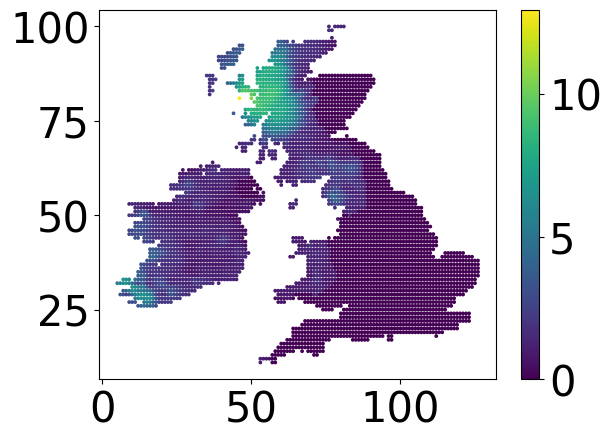

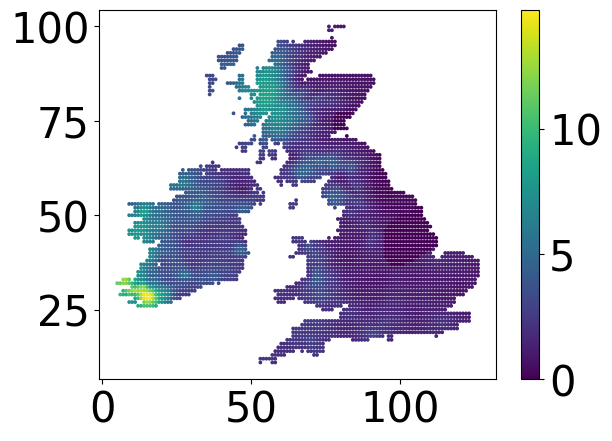

In [12]:
land = np.nonzero(GNM_output['mask'][0])
for day in range(400,402):
    
    plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=[GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],s=3)
    plt.colorbar()
    plt.show()
    

# Warning: check if the correct locations were removed

# Diagnostics

### Marginals

In [9]:
# Draw time-series plot with quantiles for predicted vs trget rain at a given location. ~3s 
# Just change values at the top.

#ts_plot_location = 3055
for ts_plot_location in [954]:
    print(ts_plot_location)
    ts_plot_left_lim,ts_plot_right_lim = ts_plot_location+0,ts_plot_location+0+360

    #################################################################### Do not touch the rest ####################################################################
    import matplotlib.dates as mdates

    # mean and 68, 95 percentiles 
    g_median = []
    g_q25 = []
    g_q75 = []
    g_q68 = []
    g_q95 = []
    g_q32 = []
    g_q05 = []

    #GNM_landonly[location][param][day]
    # 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc
    for a,b,i in zip([GNM_landonly[ts_plot_location][0][i] for i in range(len(GNM_landonly[0][0]))],[GNM_landonly[ts_plot_location][1][i] for i in range(len(GNM_landonly[0][0]))],range(len(GNM_landonly[0][0]))) :
        rv = scs.gamma(scale=1/b,a=a)  
        
        g_median.append(rv.ppf((GNM_landonly[ts_plot_location][4][i]-1+0.5)/GNM_landonly[ts_plot_location][4][i]))
        g_q25.append(rv.ppf((GNM_landonly[ts_plot_location][4][i]-1+0.25)/GNM_landonly[ts_plot_location][4][i]))
        g_q75.append(rv.ppf((GNM_landonly[ts_plot_location][4][i]-1+0.75)/GNM_landonly[ts_plot_location][4][i]))
        g_q95.append(rv.ppf((GNM_landonly[ts_plot_location][4][i]-1+0.95)/GNM_landonly[ts_plot_location][4][i]))
        g_q05.append(rv.ppf((GNM_landonly[ts_plot_location][4][i]-1+0.05)/GNM_landonly[ts_plot_location][4][i]))

    for q in [g_median,g_q25,g_q05,g_q32,g_q68,g_q75,g_q95]:
        for i in range(len(q)):
            if math.isnan(q[i]):
                q[i]=0
                
    plt.figure(figsize=(25, 8),dpi=700)
    plt.plot(day_dates,g_q05,color='skyblue',linewidth=0.6,alpha=1,label='forecast percentiles 05 to 95')
    plt.plot(day_dates,g_q25,color='navy',linewidth=0.6,alpha=1,label='forecast percentiles 25 to 75')
    plt.plot(day_dates,g_median,color='blue',linewidth=1,alpha=1,label='forcast median')
    plt.plot(day_dates,g_q75,color='navy',linewidth=0.6,alpha=1)
    plt.plot(day_dates,g_q95,color='skyblue',linewidth=0.6,alpha=1)
    plt.fill_between(day_dates, g_median, g_q75, where=([g_median[k] < g_q75[k] for k in range(len(GNM_landonly[ts_plot_location][4]))]), color='navy', alpha=0.6,interpolate=True)
    plt.fill_between(day_dates, g_median, g_q25, where=([g_median[k] > g_q25[k] for k in range(len(GNM_landonly[ts_plot_location][4]))]), color='navy', alpha=0.6,interpolate=True)
    plt.fill_between(day_dates, g_q95, g_q75, where=([g_q95[k] > g_q75[k] for k in range(len(GNM_landonly[ts_plot_location][4]))]), color='skyblue', alpha=0.6,interpolate=True)
    plt.fill_between(day_dates, g_q05, g_q25, where=([g_q05[k] < g_q25[k] for k in range(len(GNM_landonly[ts_plot_location][4]))]), color='skyblue', alpha=0.6,interpolate=True)
    plt.scatter(day_dates,[GNM_landonly[ts_plot_location][3][i] for i in range(len(GNM_landonly[0][0]))],color='r',marker='1',s=20,label='observed rain')
    plt.plot(day_dates,[GNM_landonly[ts_plot_location][3][i] for i in range(len(GNM_landonly[0][0]))],color='r',alpha=0.6,linewidth=0.3)
    plt.xlim((day_dates[ts_plot_left_lim],day_dates[ts_plot_right_lim]))
    plt.title('Gamma model at location '+str(GNM_landonly[ts_plot_location][5]))
    plt.xlabel('Day index')
    plt.ylabel('Precipitation (mm)')
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=14))
    plt.gcf().autofmt_xdate()
    plt.legend()
    plt.show()

954


In [ ]:
# Densities plots
# Just change values at the top.

density_plot_location = 111
density_plot_start,density_plot_end = 370,376

#################################################################### Do not touch the rest ####################################################################
import matplotlib

# 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc
x=[i/20 for i in range(400)]
plt.figure(figsize=(10,(density_plot_end-density_plot_start)*2))
colors = matplotlib.cm.viridis(np.linspace(0, 1, len(range(density_plot_end,density_plot_start,-1))))
for idx,col in zip(reversed(range(density_plot_start-1,density_plot_end)),colors):
    rv=scs.gamma(a=[GNM_landonly[density_plot_location][0][i] for i in range(len(GNM_landonly[ts_plot_location][4]))][idx],scale=[1/GNM_landonly[density_plot_location][1][i] for i in range(len(GNM_landonly[ts_plot_location][4]))][idx])
    level=(-0.3+(idx+1-density_plot_start)*0.25)
    plt.plot(x,level+rv.pdf(x),color='black',alpha=0.7)
    plt.fill_between(x,y1=level+rv.pdf(x),y2=level,where=([level+rv.pdf(x_)>level for x_ in x]),color=col,alpha=0.5)
    plt.text(15,level+0.03,'p= '+str(round([GNM_landonly[density_plot_location][4][i] for i in range(len(GNM_landonly[ts_plot_location][4]))][idx],2)))
    plt.scatter([GNM_landonly[density_plot_location][3][i] for i in range(len(GNM_landonly[ts_plot_location][4]))][idx],level,marker='v',color='b')
plt.xlabel('Precipitation (mm)')
plt.title('Gamma(y) in location '+str(GNM_landonly[density_plot_location][5]))
#plt.yticks([-0.3+(idx-density_plot_start)*0.25 for idx in range(density_plot_end,density_plot_start,-1)],reversed([pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date'][density_plot_start:density_plot_end]]))
#plt.yticks([-0.3+(idx-density_plot_start)*0.25 for idx in range(density_plot_end,density_plot_start,-1)],[k for k in range([density_plot_start:density_plot_end]])
plt.show()

### Simulations

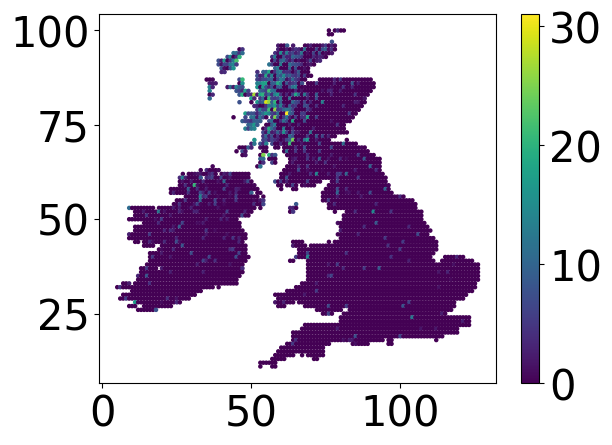

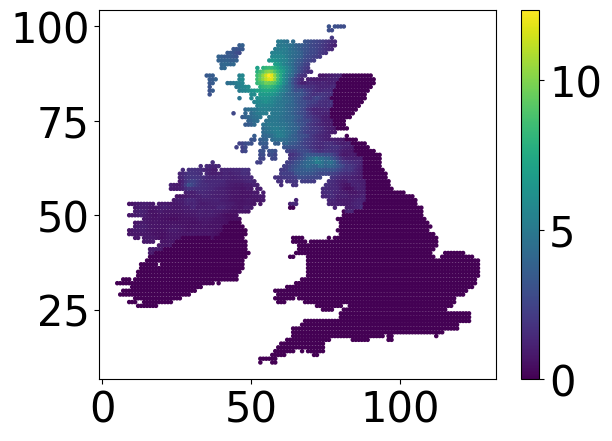

In [3]:
def sim_convCNP(day, sim_nb=1):
    '''
    Does an inverse transform sampling on the ConvCNP marginals.
    '''
    # 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc

    # Extract the required data for the given day
    p = np.array([GNM_landonly[l][4][day] for l in range(len(GNM_landonly))])
    a = np.array([GNM_landonly[l][0][day] for l in range(len(GNM_landonly))])
    scale = 1 / np.array([GNM_landonly[l][1][day] for l in range(len(GNM_landonly))])
    # Generate the uniform random numbers for inverse transform sampling
    u = np.random.uniform(low=0, high=1, size=(sim_nb,len(GNM_landonly)))
    censored_u = (u + p - 1) / p # Apply the censoring

    y = np.nan_to_num(scs.gamma(a=a, scale=scale).ppf(censored_u),nan=0) # map censored to 0 with nan_to_num
    
    return y


day = 33  
sim_nb = 100  
result = sim_convCNP(day, sim_nb)
plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=result[0],s=5)
plt.colorbar()
plt.show()

plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=[GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],s=5)
plt.colorbar()
plt.show()

In [11]:
sims_all_convCNP = np.ones((len(GNM_landonly[0][0]),100,len(GNM_landonly)))
sims_all_convCNP = sims_all_convCNP.transpose(1,0,2)

In [12]:
sims_all_convCNP.shape

(100, 7486, 4302)

In [ ]:
sims_all_convCNP=[]



for d in tqdm(range(len(GNM_landonly[0][0]))):
    sims_all_convCNP.append(sim_convCNP(d,100))

sims_all_convCNP = np.array(sims_all_convCNP).transpose(1,0,2)

  0%|          | 11/7486 [00:04<45:49,  2.72it/s]


KeyboardInterrupt: 

### ROC

In [ ]:
plt.hist(sims_all_copula.flatten(),bins=50,density=True)

In [ ]:
# ROC for samples
sims_all_copula = np.array(sims_all_convCNP)
g_0mm=np.mean(sims_all_copula>0,axis=1).flatten()
g_5mm=np.mean(sims_all_copula>5,axis=1).flatten()
g_10mm=np.mean(sims_all_copula>10,axis=1).flatten()
g_15mm=np.mean(sims_all_copula>15,axis=1).flatten()
g_20mm=np.mean(sims_all_copula>20,axis=1).flatten()
g_25mm=np.mean(sims_all_copula>25,axis=1).flatten()
all_target_rain = np.array([np.array([GNM_landonly[loc][3][day]for day in day_subset])for loc in range(len(GNM_landonly))]).flatten().reshape(len(GNM_landonly),len(day_subset))
g_0mm_did_rain=(all_target_rain.transpose()>0).flatten()
g_5mm_did_rain=(all_target_rain.transpose()>5).flatten()
g_10mm_did_rain=(all_target_rain.transpose()>10).flatten()
g_15mm_did_rain=(all_target_rain.transpose()>15).flatten()
g_20mm_did_rain=(all_target_rain.transpose()>20).flatten()
g_25mm_did_rain=(all_target_rain.transpose()>25).flatten()

In [ ]:
# getting vector of 'did it rain this much'
g_0mm=[]
g_5mm=[]
g_10mm=[]
g_15mm=[]
g_20mm=[]
g_25mm=[]

#GNM_landonly[location][param][day]
# 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc

def fast_roc(day,x):
   
   out = 1-(
         (1-np.array([GNM_landonly[l][4][day] for l in range(len(GNM_landonly))])) + 
         np.multiply(
            [GNM_landonly[l][4][day] for l in range(len(GNM_landonly))] , 
            scs.gamma( scale=[1/GNM_landonly[l][1][day] for l in range(len(GNM_landonly))] , 
                        a=[GNM_landonly[l][0][day] for l in range(len(GNM_landonly))]
               ).cdf(x)
            )        
      )

   return out


for d in tqdm(range(len(GNM_landonly[0][0]))):
   g_0mm.append(fast_roc(d,0.01))
   g_5mm.append(fast_roc(d,5))
   g_10mm.append(fast_roc(d,10))
   g_15mm.append(fast_roc(d,15))
   g_20mm.append(fast_roc(d,20))
   g_25mm.append(fast_roc(d,25))


with open('g_0mm.txt','wb') as f:
   pickle.dump(g_0mm,f)

with open('g_5mm.txt','wb') as f:
   pickle.dump(g_5mm,f)

with open('g_10mm.txt','wb') as f:
   pickle.dump(g_10mm,f)

with open('g_15mm.txt','wb') as f:
   pickle.dump(g_15mm,f)

with open('g_20mm.txt','wb') as f:
   pickle.dump(g_20mm,f)

with open('g_25mm.txt','wb') as f:
   pickle.dump(g_25mm,f)


In [ ]:
g_0mm_did_rain=[]
g_5mm_did_rain=[]
g_10mm_did_rain=[]
g_15mm_did_rain=[]
g_20mm_did_rain=[]
g_25mm_did_rain=[]
def roc_didrain(day,x):
    return np.array([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))])>x
for d in tqdm(range(len(GNM_landonly[0][0]))):
   g_0mm_did_rain.append(roc_didrain(d,0.01))
   g_5mm_did_rain.append(roc_didrain(d,5))
   g_10mm_did_rain.append(roc_didrain(d,10))
   g_15mm_did_rain.append(roc_didrain(d,15))
   g_20mm_did_rain.append(roc_didrain(d,20))
   g_25mm_did_rain.append(roc_didrain(d,25))

In [ ]:
#Saving data
'''with open('g_0mm.txt','wb') as f:
    pickle.dump(g_0mm,f)
with open('g_5mm.txt','wb') as f:
    pickle.dump(g_5mm,f)
with open('g_10mm.txt','wb') as f:
    pickle.dump(g_10mm,f)
with open('g_15mm.txt','wb') as f:
    pickle.dump(g_15mm,f)
with open('g_20mm.txt','wb') as f:
    pickle.dump(g_20mm,f)
with open('g_25mm.txt','wb') as f:
    pickle.dump(g_25mm,f)'''

# Loading data
 
with open('g_0mm.txt','rb') as f:
    g_0mm = pickle.load(f)
with open('g_5mm.txt','rb') as f:
    g_5mm = pickle.load(f)
with open('g_10mm.txt','rb') as f:
    g_10mm = pickle.load(f)
with open('g_15mm.txt','rb') as f:
    g_15mm = pickle.load(f)
with open('g_20mm.txt','rb') as f:
    g_20mm = pickle.load(f)
with open('g_25mm.txt','rb') as f:
    g_25mm = pickle.load(f)

In [ ]:
# Restructuring data for ROC ~1m+3m/20y , 6m/30y

# g_25mm[loc][parallel run][0:rained more than x, 1:P it rained x][days]
roc_0_tf = np.array(g_0mm_did_rain).flatten()
roc_0_p = np.array(g_0mm).flatten()

roc_5_tf = np.array(g_5mm_did_rain).flatten()
roc_5_p = np.array(g_5mm).flatten()

roc_10_tf = np.array(g_10mm_did_rain).flatten()
roc_10_p = np.array(g_10mm).flatten()

roc_15_tf = np.array(g_15mm_did_rain).flatten()
roc_15_p = np.array(g_15mm).flatten()

roc_20_tf = np.array(g_20mm_did_rain).flatten()
roc_20_p = np.array(g_20mm).flatten()

roc_25_tf = np.array(g_25mm_did_rain).flatten()
roc_25_p = np.array(g_25mm).flatten()

###

fpr_0mm, tpr_0mm, _ = metrics.roc_curve(roc_0_tf,roc_0_p)
auc0 = metrics.roc_auc_score(roc_0_tf,roc_0_p)

fpr_5mm, tpr_5mm, _ = metrics.roc_curve(roc_5_tf,roc_5_p)
auc5 = metrics.roc_auc_score(roc_5_tf,roc_5_p)

fpr_10mm, tpr_10mm, _ = metrics.roc_curve(roc_10_tf,roc_10_p)
auc10 = metrics.roc_auc_score(roc_10_tf,roc_10_p)

fpr_15mm, tpr_15mm, _ = metrics.roc_curve(roc_15_tf,roc_15_p)
auc15 = metrics.roc_auc_score(roc_15_tf,roc_15_p)

fpr_20mm, tpr_20mm, _ = metrics.roc_curve(roc_20_tf,roc_20_p)
auc20 = metrics.roc_auc_score(roc_20_tf,roc_20_p)

fpr_25mm, tpr_25mm, _ = metrics.roc_curve(roc_25_tf,roc_25_p)
auc25 = metrics.roc_auc_score(roc_25_tf,roc_25_p)

In [ ]:
# ROC plot ~3m
plt.figure(figsize=(10,10))
plt.plot(fpr_0mm,tpr_0mm,label='AUC='+str(auc0),color='black',alpha=0.7)

plt.plot(fpr_5mm,tpr_5mm,label='AUC='+str(auc5),color='red',alpha=0.7)

plt.plot(fpr_10mm,tpr_10mm,label='AUC='+str(auc10),color='orange',alpha=0.7,linestyle='dashed')

plt.plot(fpr_15mm,tpr_15mm,label='AUC='+str(auc15),color='green',alpha=0.7,linestyle='dashdot')

plt.plot(fpr_20mm,tpr_20mm,label='AUC='+str(auc20),color='blue',alpha=0.7,linestyle='dotted')

plt.plot(fpr_25mm,tpr_25mm,label='AUC='+str(auc25),color='purple',alpha=0.7)

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(['0mm AUC:'+str(round(auc0,5)),'5mm AUC:'+str(round(auc5,5)),'10mm AUC:'+str(round(auc10,5)),'15mm AUC:'+str(round(auc15,5)),'20mm AUC:'+str(round(auc20,5)),'25mm AUC:'+str(round(auc25,5))])
#plt.title('Gamma Model United Kingdom')
#plt.savefig('ROC Gamma model UK')

### 1 - ecdf

In [ ]:
# P(rain>x) ~1m15 now. depending on samples and days used. 
from statsmodels.distributions.empirical_distribution import ECDF

# get empirical cdfs for median, sampled and target rain.
gamma_ecdf = ECDF(g_median_all.flatten())
target_ecdf = ECDF(np.array([np.array([GNM_landonly[loc][3][day] for loc in range(len(GNM_landonly))]) for day in tqdm(range(len(GNM_landonly[0][0])))]).flatten())
gamma_sampled_ecdf = ECDF(np.array(sims_all_convCNP).flatten())
plt.plot(gamma_ecdf.x,1-gamma_ecdf.y,label='Median forecast')
plt.plot(gamma_sampled_ecdf.x,1-gamma_sampled_ecdf.y,linestyle='dotted',label='Sampled forecasts')
plt.plot(target_ecdf.x,1-target_ecdf.y,linestyle='--',label='Target rainfall')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Probability of precipitatoin > x')
plt.xlim(-1,25)
plt.legend()

### RMSB MAB

In [14]:
sims_all_convCNP.shape

(100, 7486, 4302)

In [ ]:
RMSE = np.zeros(sims_all_convCNP.shape[2])

#3 mins
for day in tqdm(range(sims_all_convCNP.shape[1])):
    RMSE = RMSE + np.power(
        np.subtract(
            [GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],
            sims_all_convCNP[:,day,:].mean(0)
            ),2)

RMSE = np.sqrt(RMSE/sims_all_convCNP.shape[1])
np.save('RMSE_Conv_CNP.npy',RMSE)

100%|██████████| 7486/7486 [00:54<00:00, 136.30it/s]


In [ ]:
MAE = np.zeros(sims_all_convCNP.shape[2])

#3 mins
for day in tqdm(range(sims_all_convCNP.shape[1])):
    MAE = MAE + np.abs(
        np.subtract(
            [GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],
            np.median(sims_all_convCNP[:,day,:],0)
            ))

MAE = MAE/sims_all_convCNP.shape[1]
np.save('MAE_Conv_CNP.npy',MAE)

100%|██████████| 7486/7486 [00:45<00:00, 165.78it/s]


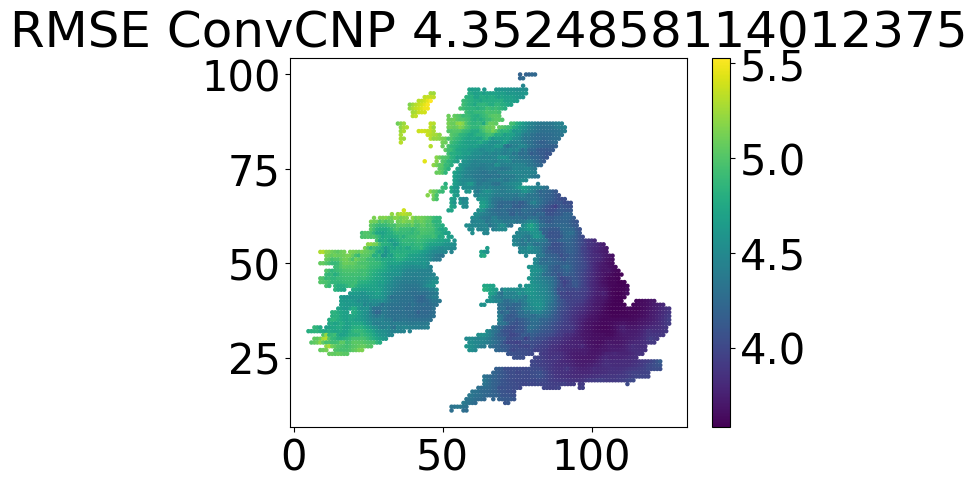

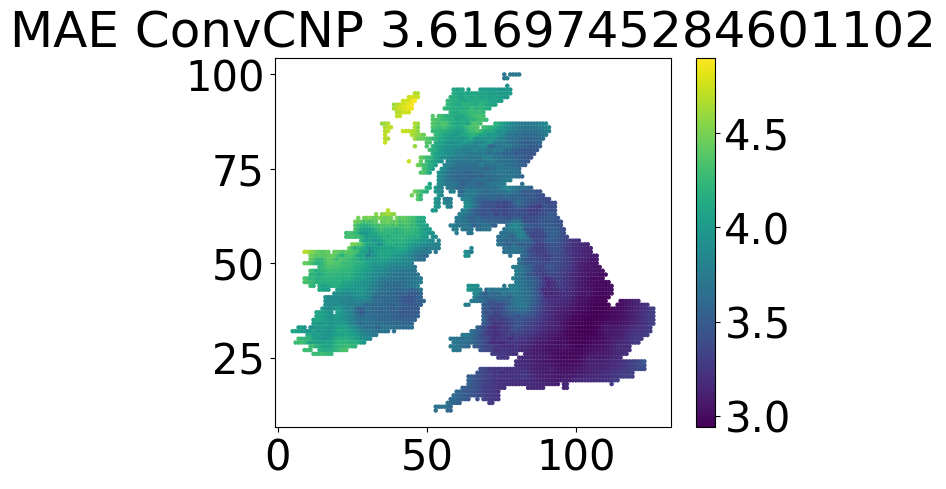

In [70]:
plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=RMSE,s=5)
plt.colorbar()
plt.title(f'RMSE ConvCNP {np.mean(RMSE)}')
plt.show()
plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=MAE,s=5)
plt.colorbar()
plt.title(f'MAE ConvCNP {np.mean(MAE)}')    
plt.show()

### Bias Maps

In [ ]:
# Bias maps 2*2
test_arr = np.array([np.mean(sampled_rain_flatten_all.reshape(3,53118)[:,column]) for column in range(53118)]).reshape(13,4086)

MAB_map = [np.mean(MAB_matrix[loc,:]) for loc in range(4086)]
RMSB_map = [math.sqrt(np.mean(RMSB_matrix[loc,:])) for loc in range(4086)]
Bias_map = np.matrix(np.array(g_median_all).reshape((4087,2000))-all_target_rain).mean(1).tolist()[:-1]
day_subset = np.random.choice(range(2000),50)
Sampled_bias = np.divide(np.array([np.mean(test_arr[:,loc]) for loc in range(4086)])-np.array([np.mean(np.transpose(all_target_rain[loc,day_subset])) for loc in range(4086)]), # difference 
np.array([np.mean(np.transpose(all_target_rain[loc,day_subset])) for loc in range(4086)])) # normalize by average target

fig, axes = plt.subplots(nrows=2, ncols=2,sharex=True,sharey=True,figsize=(12.5,8.5))
for day,ax in tqdm(enumerate(axes.flat)):
    
    fig.set_dpi(500)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticklabels([])
    plt.subplots_adjust(wspace=0, hspace=0)
    if day==0:
        #ax.set_title('MAB of median', y=1.0, pad=-10,size=10)
        im=ax.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=MAB_map,s=3.3,marker='s')
        fig.colorbar(im,ax=ax,location='left',fraction=0.03,pad=0.001).ax.tick_params(labelsize=3) 
        
    elif day==1:
        #ax.set_title('RMSB of median', y=1.0, pad=-10,size=10)
        im=ax.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=RMSB_map,s=3.3,marker='s')
        fig.colorbar(im,ax=ax,location='left',fraction=0.03,pad=0.001)
    elif day==2:
        #ax.set_title('Bias of median', y=1.0, pad=-10,size=10)
        im=ax.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=Bias_map,cmap='BrBG',s=3.3,marker='s',vmin=-4,vmax=4)
        fig.colorbar(im,ax=ax,location='left',fraction=0.03,pad=0.001)
    else:
        #ax.set_title('Bias of 10 averaged samples', y=1.0, pad=-10,size=10)
        im=ax.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=Sampled_bias,cmap='BrBG',s=3.3,marker='s',vmin=-5,vmax=5)
        fig.colorbar(im,ax=ax,location='left',fraction=0.03,pad=0.001)

plt.show()

In [ ]:

for map_id,map in enumerate([MAB_map,RMSB_map,Bias_map,Sampled_bias]):
    fig = plt.gcf()
    fig.set_size_inches(12,9.5)
    if map_id in [2,3]:
        plt.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=map,cmap='BrBG',s=24,marker='s',vmin=-np.max(np.abs(map)),vmax=np.max(np.abs(map)))
        plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
        plt.yticks([])
        plt.xticks([])
        plt.show()
        continue
    plt.scatter([GNM_landonly[loc][5][1] for loc in range(4086)],[-GNM_landonly[loc][5][0] for loc in range(4086)],c=map,s=24,marker='s',vmin=0)
    plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
    plt.yticks([])
    plt.xticks([])
    plt.show()

### Median VS Observed

In [ ]:
# median vs observed
binned_median_means = [np.log(np.mean(g_median_all[np.logical_and(all_target_rain.flatten()>-0.01+k*3, all_target_rain.flatten()<3+k*3     )])+1) for k in range(30)]
binned_median_std = [np.std(np.log(1+g_median_all[np.logical_and(all_target_rain.flatten()>-0.01+k*3, all_target_rain.flatten()<3+k*3     )])) for k in range(30)]

plt.plot(np.log([i for i in range(1,30*3,3)]),binned_median_means, color='red',linestyle='dashed',label='Mean/SD of pred in 3mm/day intervals')

for i,v in enumerate(range(1,30*3,3)):
    if i==0:
        continue
    plt.plot(np.log([v,v]),[binned_median_means[i]+binned_median_std[i] ,binned_median_means[i]-binned_median_std[i] ],'r',linewidth=1)

plt.plot([0,5],[0,5],linestyle='dashed',color='grey',label='y = x')
plt.scatter(np.log(all_target_rain.flatten()+1),np.log(g_median_all+1),marker='x',linewidths=0.3,alpha=0.3)

plt.axvline(x = np.log(10), color = 'purple', label = '10 mm rainfall',linewidth=1.3)

plt.legend(loc='upper left')

plt.xlabel('Observed log-trandformed rainfall')
plt.ylabel('Predicted log-trandformed rainfall')
plt.show()

### CRPS

In [ ]:
# compute CRPS per locatoin. This is done in the medium benchmark paper. Also, I can then plot CRPs on a map, could be nice.

In [15]:
def estimate_CRPS_score_fast(obs,sims):
    '''
    obs: one vector of observations [y_1, y_2, ... y_n], ideally n corresponds to locations.
    sims: m vectors of simulations, each vector has length n. [[x_11, x_21,..., x_n1] ,..., [x_1m, x_2m,..., x_nm] ]

    returns: a vector [s1, ... , sn] of one score per location. this is for a single day, so would still need to average across days.
    '''
    m = len(sims)

    obs= np.array(obs)
    sims=np.array(sims)

    # |X-x|    
    diff_X_x = np.mean(
        np.abs(
            np.tile(obs,(m,1)) - sims
            ),
        axis=0)

    #|X-X'|
    diff_X_tilde_X = np.sum(
        np.abs(
            np.tile(sims,(m,1))-
            np.repeat(sims,m,axis=0)
            )
            ,axis=0
        )/(m*m-1)

    return 2*diff_X_x - diff_X_tilde_X 


In [16]:
sims_all_convCNP.shape

(100, 7486, 4302)

In [ ]:
SR_crps = np.zeros((sims_all_convCNP.shape[1],4302))
for day in tqdm(range(sims_all_convCNP.shape[1])):
    SR_crps[day] = estimate_CRPS_score_fast([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],sims_all_convCNP[:,day,:])


np.save('SR_Conv_CNP_crps.npy',SR_crps)

100%|██████████| 50/50 [00:40<00:00,  1.24it/s]


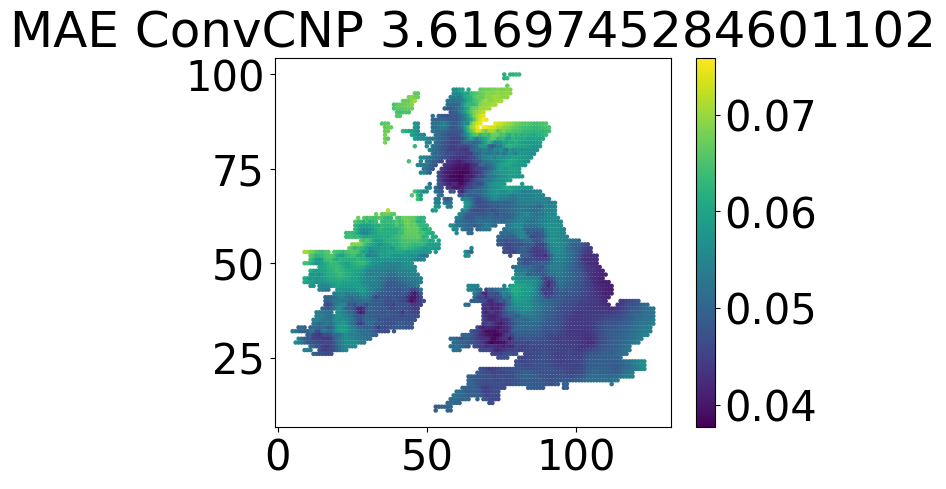

In [80]:
plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],c=SR_crps.mean(0),s=5)
plt.colorbar()
plt.title(f'MAE ConvCNP {np.mean(MAE)}')    
plt.show()

### Energy score

In [19]:
import torch
import torch.nn as nn
from torch import tensor as tt

def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

In [33]:
SR_energy = []
for day in tqdm(range(len(GNM_landonly[0][0]))):
    SR_energy.append(Energy_Score(0.5,tt([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]).unsqueeze(0),tt(sims_all_convCNP[:,day,:])))

plt.scatter(range(len(SR_energy)),SR_energy)
print(np.mean(SR_energy))
np.save('SR_energy_Conv_CNP.npy', SR_energy)

 10%|▉         | 727/7486 [00:07<01:10, 95.47it/s] 


KeyboardInterrupt: 

### Spatial Scoring Rule

In [29]:
from sklearn.metrics.pairwise import euclidean_distances 

def Variogram_single_day(observations_y,simulations_Y,distance_matrix):

    n = len(observations_y)
    m = len(simulations_Y)
    y = np.array(observations_y)
    Y = np.array(simulations_Y)

    # inverse distance matrix, for weights w_ij:
    w_ij = np.nan_to_num( 1/distance_matrix, copy=False, nan=0, posinf=0, neginf=0)

    # |y_i - y_j| first part of Variogram
    diff_y_y = euclidean_distances(y.reshape(-1,1))

    # |Y_k,i - Y_k,j| second part of Variogram
    diff_Y_Y = np.mean(np.abs(np.tile(Y,n).reshape(m,n*n)-np.repeat(Y,n).reshape(m,n*n)),axis=0).reshape(n,n)

    Variogram = np.multiply(
        w_ij,
        np.power(
            diff_y_y - diff_Y_Y
        ,2)
    )

    return np.sum(Variogram)

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))


In [35]:
Variogram_diagnostic = []
for d in tqdm(range(len(GNM_landonly[0][0]))):
    Variogram_diagnostic.append(Variogram_single_day(tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]),
                     tt(sims_all_convCNP[:10,d,:]),
                     dist_mat))

np.save('SR_Variogram_Conv_CNP_testset.npy', Variogram_diagnostic)

  0%|          | 0/7486 [00:00<?, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_2640\2693743445.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(observations_y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_2640\2693743445.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Y = np.array(simulations_Y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_2640\2693743445.py:11: RuntimeWarning: divide by zero encountered in divide
  w_ij = np.nan_to_num( 1/di

KeyboardInterrupt: 

### Rank histogram

In [ ]:
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

def get_cdf_gnm(day):
    p_times_cdf = np.multiply( #p*cdf(y)
        np.array([GNM_landonly[l][4][day] for l in range(len(GNM_landonly))]),
        scs.gamma(
            a=[GNM_landonly[l][0][day] for l in range(len(GNM_landonly))],
            scale=[1/GNM_landonly[l][1][day] for l in range(len(GNM_landonly))]
            ).cdf([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]))
    
    where_0 = np.argwhere(p_times_cdf==0).flatten()
    where_rain = np.argwhere(p_times_cdf>0).flatten()

    p_times_cdf[where_0] = np.random.uniform( # replace censored by u~[0,1-p]
        low=np.zeros(len(where_0)),
        high=(1-np.array([GNM_landonly[l][4][day] for l in range(len(GNM_landonly))])[where_0]).flatten()
        )
    
    p_times_cdf[where_rain] = (1-np.array([GNM_landonly[l][4][day] for l in range(len(GNM_landonly))]))[where_rain] + p_times_cdf[where_rain] # uncensored = (1-p) + p*cdf(y)

    return p_times_cdf

In [ ]:
obs_u_all = []
for d in tqdm(range(len(GNM_landonly[0][0]))):
    obs_u_all.append(get_cdf_gnm(d))

In [ ]:
obs_u_all = np.array(obs_u_all).flatten()

In [ ]:
plt.hist(obs_u_all,bins=25,density=True,alpha=0.7) # convcnp

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter( range(len(obs_u_all)),obs_u_all,s=0.000005)
plt.show()

In [ ]:
plt.figure(figsize=(5,6.5))
plt.hist(obs_u_all,bins=30,density=True,alpha=0.7)
plt.plot([0,1],[1,1])
plt.ylim(0,3)
plt.show()
plt.figure(figsize=(20,5))
plt.hist(obs_u_all,bins=100,density=True,alpha=0.7)
plt.plot([0,1],[1,1])   
plt.ylim(0,5)
plt.show()

In [ ]:
plt.hist(obs_u_all,bins=100,cumulative=True,alpha=0.7,align='mid')
plt.plot([0,1],[0,len(obs_u_all)],linestyle='dashed')
plt.show()
plt.figure(figsize=(20,5))
plt.hist(obs_u_all,bins=500,cumulative=True,alpha=0.7,align='mid',histtype='step',linewidth=2)
plt.plot([0,1],[0,len(obs_u_all)],linestyle='dashed')
plt.show()

### Covariance vs Distance

In [39]:
def compute_average_corr_per_dist(all_corr, dist_mat):
    ''' 
    Compute the average correlation per distance, following dist_mat as the distance mask.
    '''
    unique_distances = np.sort(np.unique(dist_mat))
    average_corr_per_dist = []
    std_corr_per_dist = []
    for d in tqdm(unique_distances):
        if d == 0:
            continue
        mask = (dist_mat == d)
        average_corr_per_dist.append(np.mean(all_corr[mask]))
        std_corr_per_dist.append(np.std(all_corr[mask]))
    return average_corr_per_dist, std_corr_per_dist

# 6 mins


corr_per_dist_sims_Conv_CNP, std_per_dist_sims_Conv_CNP = compute_average_corr_per_dist(np.cov(np.concatenate(sims_all_convCNP[:10]).T), dist_mat)

corr_per_dist_obs, std_per_dist_obs = compute_average_corr_per_dist(np.cov(tt([GNM_landonly[l][3][:len(GNM_landonly[0][3])] for l in range(len(GNM_landonly))])), dist_mat)

100%|██████████| 3468/3468 [01:21<00:00, 42.65it/s]


In [40]:
np.save('corr_per_dist_sims_Conv_CNP.npy', corr_per_dist_sims_Conv_CNP)
np.save('std_per_dist_sims_Conv_CNP.npy', std_per_dist_sims_Conv_CNP)

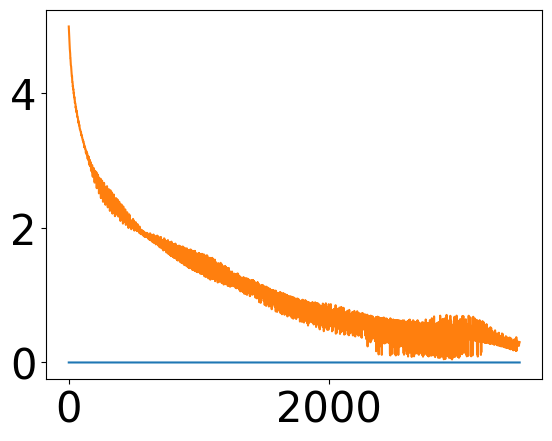

In [41]:
plt.plot(corr_per_dist_sims_Conv_CNP)
plt.plot(corr_per_dist_obs)

### Spatio-temporal pooling

100


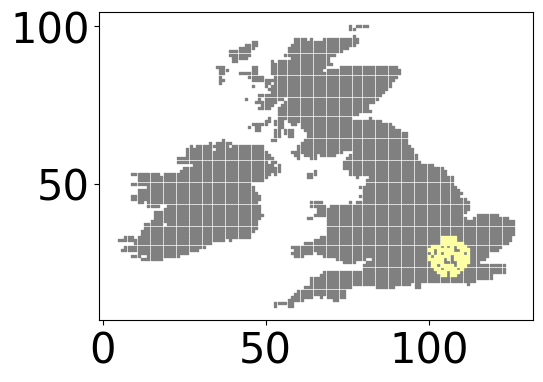

In [ ]:
# 0'pred_alpha', 1'pred_beta', 2 rain>0 , 3'target_rain', 4 pred_p, 5 loc

def generate_subsample_locs(locs_nb, random_center = 3906): # London 3906 # Glasgow 738 # Dublin 2350
    locs=[]
    while len(locs)<locs_nb:
        #random_center = np.random.choice(range(len(GNM_landonly))) 
 
        locs = np.where([math.dist(GNM_landonly[k][5],GNM_landonly[random_center ][5])<(np.sqrt(locs_nb/np.pi)+0.7) for k in range(len(GNM_landonly))])[0]
    return np.random.choice(locs,size=locs_nb,replace=False)    

fig = plt.gcf() 
fig.set_size_inches(5.6,4)
locs = generate_subsample_locs(locs_nb=100)
print(len(locs))

plt.scatter([GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],[GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],
c='grey',s=3,marker='s')

plt.scatter([GNM_landonly[l][5][0] for l in locs],[GNM_landonly[l][5][1] for l in locs],
c=[GNM_landonly[loc][3][300] for loc in locs],
cmap='inferno_r',s=3,marker='s')


plt.show()

In [91]:
# Computing the aggregate rainfall in area for a sequence of x days. Each such sequence of aggregate values is one sample from the spatio-temporal distribution over aggregate rain. 
# Compute CRPS for aggregate on one day - per day. Here just do CRPS(avg,[avg(sim_i) for i])
def estimate_CRPS_score_fast(obs,sims):
    '''
    obs: one vector of observations [y_1, y_2, ... y_n], ideally n corresponds to locations.
    sims: m vectors of simulations, each vector has length n. [[x_11, x_21,..., x_n1] ,..., [x_1m, x_2m,..., x_nm] ]

    returns: a vector [s1, ... , sn] of one score per location. this is for a single day, so would still need to average across days.
    '''
    m = len(sims)

    obs= np.array(obs)
    sims=np.array(sims)

    # |X-x|    
    diff_X_x = np.mean(
        np.abs(
            np.tile(obs,(m,1)) - sims
            ),
        axis=0)

    #|X-X'|
    diff_X_tilde_X = np.sum(
        np.abs(
            np.tile(sims,(m,1))-
            np.repeat(sims,m,axis=0)
            )
            ,axis=0
        )/(m*m-1)

    return 2*diff_X_x - diff_X_tilde_X 

CRPS_spatial_rain_total_day_sims_a0 = estimate_CRPS_score_fast(np.array([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(len(GNM_landonly[0][3]))]),np.mean(sims_all_convCNP[:,:len(GNM_landonly[0][3]),locs],2))
CRPS_spatial_rain_total_day_sims_a0 = CRPS_spatial_rain_total_day_sims_a0[np.isfinite(CRPS_spatial_rain_total_day_sims_a0)]

In [92]:
# Compute Energy on sequences of x days. 

Energy_spatiotemporal_2_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-2)):
    Energy_spatiotemporal_2_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+2)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+2,locs],2)).to(dtype=torch.float32),
        ))

Energy_spatiotemporal_3_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-3)):
    Energy_spatiotemporal_3_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+3)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+3,locs],2)).to(dtype=torch.float32),
        ))            
    
Energy_spatiotemporal_4_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-4)):
    Energy_spatiotemporal_4_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+4)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+4,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_5_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-5)):
    Energy_spatiotemporal_5_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+5)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+5,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_6_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-6)):
    Energy_spatiotemporal_6_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+6)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+6,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_7_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-7)):
    Energy_spatiotemporal_7_rain_total_sims_a0.append(
        Energy_Score(0.5,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+7)]).unsqueeze(0),
            tt(np.mean(sims_all_convCNP[:,day_window_index:day_window_index+7,locs],2)).to(dtype=torch.float32),
        ))

np.save('Energy_spatiotemporal_1_London_rain_total_sims_Conv_CNP.npy', CRPS_spatial_rain_total_day_sims_a0)                               
np.save('Energy_spatiotemporal_2_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_2_rain_total_sims_a0)
np.save('Energy_spatiotemporal_3_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_3_rain_total_sims_a0)
np.save('Energy_spatiotemporal_4_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_4_rain_total_sims_a0)
np.save('Energy_spatiotemporal_5_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_5_rain_total_sims_a0)
np.save('Energy_spatiotemporal_6_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_6_rain_total_sims_a0)
np.save('Energy_spatiotemporal_7_London_rain_total_sims_Conv_CNP.npy', Energy_spatiotemporal_7_rain_total_sims_a0)

100%|██████████| 7479/7479 [00:07<00:00, 989.79it/s] 


### Correlation map

In [ ]:
with open('VAEGAN_corr_sims.txt','rb') as f:
    VAEGAN_corr_sims = pickle.load(f)

In [ ]:
# Observed corr
#corr_mat = np.corrcoef(all_target_rain)
fig = plt.gcf() 
fig.set_size_inches(14,10)
plt.scatter(VAEGAN_corr_sims[0],VAEGAN_corr_sims[1],c=VAEGAN_corr_sims[2],s=35,marker='s',vmin=0)
plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
plt.plot([76,76],[0,-100],color='black',linestyle='dotted',linewidth=1)
plt.plot([0,140],[-46,-46],color='black',linestyle='dotted',linewidth=1)
plt.yticks([])
plt.xticks([])
plt.tight_layout()

plt.savefig('VAEGAN_corr_sims.eps', format='eps')
plt.show()

In [ ]:
for i,v in enumerate(np.array([GNM_landonly[l][5] for l in range(len(GNM_landonly))])): # closest to center 1107 [43 70]

    if (v==[76,54]).all():
        print(i,v)

In [ ]:
all_target_rain = np.array([np.array([GNM_landonly[loc][3][day]for day in range(len(GNM_landonly[0][0]))])for loc in range(len(GNM_landonly))]).flatten().reshape(len(GNM_landonly),len(GNM_landonly[0][0])) # [loc,day]


In [ ]:
# Observed corr
#corr_mat = np.corrcoef(all_target_rain)
fig = plt.gcf() 
fig.set_size_inches(1.5*12.1,1.5*9.1)
plt.scatter([GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))],[GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],c=corr_mat[:,2361  ],s=35,marker='s',vmin=0)
plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
plt.plot([76,76],[0,100],color='black',linestyle='dotted',linewidth=1)
plt.plot([0,140],[54,54],color='black',linestyle='dotted',linewidth=1)
plt.yticks([])
plt.xticks([])
plt.show()

In [ ]:
# Simulated corr
plt.rcParams.update({'font.size': 30})

sims_all_convCNP = np.array(sims_all_convCNP)
corr_mat_sim = np.corrcoef(np.concatenate(sims_all_convCNP,0).transpose())
fig = plt.gcf() 
fig.set_size_inches(14,10)
plt.tight_layout()
plt.scatter([GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))],[GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],c=corr_mat_sim[2361,:],s=35,marker='s',vmin=0)
plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
plt.plot([76,76],[0,100],color='black',linestyle='dotted',linewidth=1)
plt.plot([0,140],[54,54],color='black',linestyle='dotted',linewidth=1)
plt.yticks([])
plt.xticks([])
plt.tight_layout()
plt.savefig('convCNP_corr_sims.eps', format='eps')
plt.show()

In [ ]:
# median of sim corr
corr_mat_sim_med = np.corrcoef(np.median(np.array(sims_all_convCNP).transpose(),axis=1))
fig = plt.gcf() 
fig.set_size_inches(1.5*12.1,1.5*9.1)
plt.scatter([GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))],[GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],c=corr_mat_sim_med[2361,:],s=35,marker='s',vmin=0)
plt.colorbar(location='bottom',fraction=0.0652,pad=0.001)
plt.plot([76,76],[0,100],color='black',linestyle='dotted',linewidth=1)
plt.plot([0,140],[54,54],color='black',linestyle='dotted',linewidth=1)
plt.yticks([])
plt.xticks([])
plt.show()

### Combined diagnostics

In [ ]:
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 30})
fig = plt.gcf() 
fig.set_size_inches(14,10)
plt.plot([0,5,10,15,20,25],[0.8601,0.8347,0.8403,0.8441,0.8448,0.8382],marker='.',linewidth=5,markersize=20,label='Cens-JGNM')
plt.plot([0,5,10,15,20,25],[0.8393,0.8234,0.8256,0.821,0.8357,0.8405],marker='.',linewidth=5,markersize=20,label='ConvCNP')
plt.plot([0,5,10,15,20,25],[0.7631,0.6873,0.6259,0.5774,0.5442,0.5219],marker='.',linewidth=5,markersize=20,label='VAEGAN')
plt.ylim((0.5,0.9))
plt.xlabel('Precipitation threshold (mm)')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig('combind_AUC_3models.eps', format='eps')
plt.show()